# Proyecto Final de Ciencia de Datos

### Mateo Reyes Rangel - AL07179280

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargamos de datos
df  = pd.read_csv('train.csv')

# Limpieza de datos (Valores faltantes y limpieza de los vecindarios)
columnas_con_nulos = ['bedrooms', 'bathrooms', 'beds']
for col in columnas_con_nulos:
    df[col] = df[col].fillna(df[col].median())

df['neighbourhood'] = df['neighbourhood'].fillna('Unknow')

# Corrección de Outliers
df = df[df['log_price'] > 0]
df = df[df['bedrooms'] <= 8]
df = df[df['accommodates'] <= 12]

# Preparación del vecindario (Solo usaremos los 10 más frecuentes)
top_vecindarios = df['neighbourhood'].value_counts().head(10).index
df['neighbourhood_limpio'] = df['neighbourhood'].apply(lambda x: x if x in top_vecindarios else 'Otro')

# Convertimos el texto a columnas numéricas (0 y 1)
df_dummies = pd.get_dummies(df['neighbourhood_limpio'], prefix='vecindario')
df = pd.concat([df,df_dummies], axis=1)

print("Limpieza de datos y vecindarios completa.")
print(f"Nuevas columnas generadas para el modelo:\n{df_dummies.columns.tolist()}")


Limpieza de datos y vecindarios completa.
Nuevas columnas generadas para el modelo:
['vecindario_Bedford-Stuyvesant', 'vecindario_Bushwick', 'vecindario_Harlem', "vecindario_Hell's Kitchen", 'vecindario_Hollywood', 'vecindario_Mid-Wilshire', 'vecindario_Otro', 'vecindario_Unknow', 'vecindario_Upper West Side', 'vecindario_Venice', 'vecindario_Williamsburg']


In [ ]:
# Actualizamos nuestra selección de variables 
X_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds'] + df_dummies.columns.tolist()
Y_col = 'log_price'

print(f"El modelo analizará: {len(X_cols)} variables en total.")

El modelo analizará: 15 variables en total.


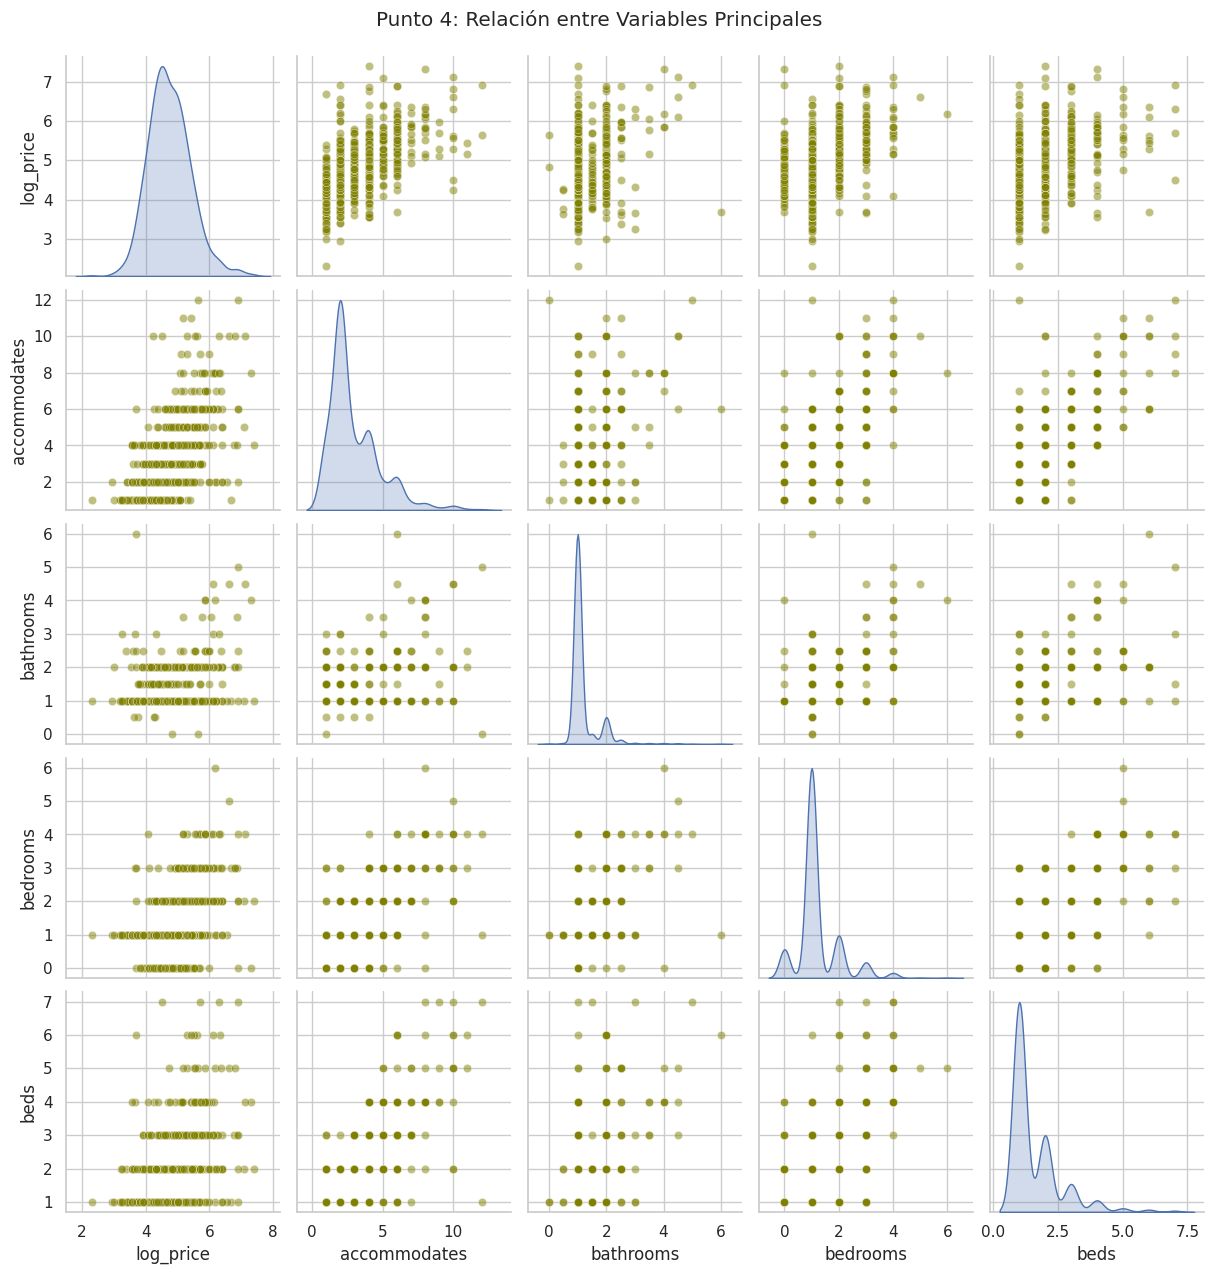

In [6]:
# Análisis de correlación
vars_para_graficar = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds']

sns.set_theme(style="whitegrid")
plot_data = df[vars_para_graficar].sample(1000, random_state = 42)

# generemos el pairplot 
g = sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.5, 'color' : 'olive'})
g.fig.suptitle("Punto 4: Relación entre Variables Principales", y=1.02)
plt.show()

In [7]:
# Definimos X y y 
X = df[X_cols]
y = df[Y_col]

# Dividimos nuestros datos (80% y 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} registros | Prueba: {X_test.shape[0]} registros")

Entrenamiento: 58890 registros | Prueba: 14723 registros


In [8]:
# Cremamos el objeto del modelo
modelo_airbnb = LinearRegression()

# Entrenamos el modelo
modelo_airbnb.fit(X_train, y_train)

# Mostramos los coeficientes para ver que variable pesa más
coeficientes = pd.DataFrame({'Variable': X_cols, 'Coeficiente' : modelo_airbnb.coef_})

print(coeficientes.sort_values(by='Coeficiente', ascending = False))


                         Variable  Coeficiente
7       vecindario_Hell's Kitchen     0.400998
12     vecindario_Upper West Side     0.325825
13              vecindario_Venice     0.249344
0                    accommodates     0.206102
2                        bedrooms     0.100161
1                       bathrooms     0.098006
14        vecindario_Williamsburg     0.074146
10                vecindario_Otro     0.057149
6               vecindario_Harlem    -0.043077
3                            beds    -0.083984
8            vecindario_Hollywood    -0.099956
9         vecindario_Mid-Wilshire    -0.130856
11              vecindario_Unknow    -0.187163
4   vecindario_Bedford-Stuyvesant    -0.284463
5             vecindario_Bushwick    -0.361946


In [9]:
# Realizamos predicciones para evaluar
y_pred_train = modelo_airbnb.predict(X_train)
y_pred_test = modelo_airbnb.predict(X_test)

# Calculamos el r2
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Evaluación de calidad
print(f"R2 en Entrenamiento: {r2_train:.4f}")
print(f"R2 en Prueba (Validación): {r2_test:.4f}")

R2 en Entrenamiento: 0.3730
R2 en Prueba (Validación): 0.3865


In [10]:
# Comparación de valores
df_comparativo = pd.DataFrame({'Real': y_test, 'Predicción' : y_pred_test})
print(df_comparativo.head())

# Error cuadratico
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

# Metricas de error
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del MSE (RMSE): {rmse:.4f}")


           Real  Predicción
48771  3.912023    4.496189
34982  4.094345    4.254803
43468  4.828314    4.924636
68003  5.010635    4.496254
34999  4.727388    5.406917
Error Cuadrático Medio (MSE): 0.3034
Raíz del MSE (RMSE): 0.5508


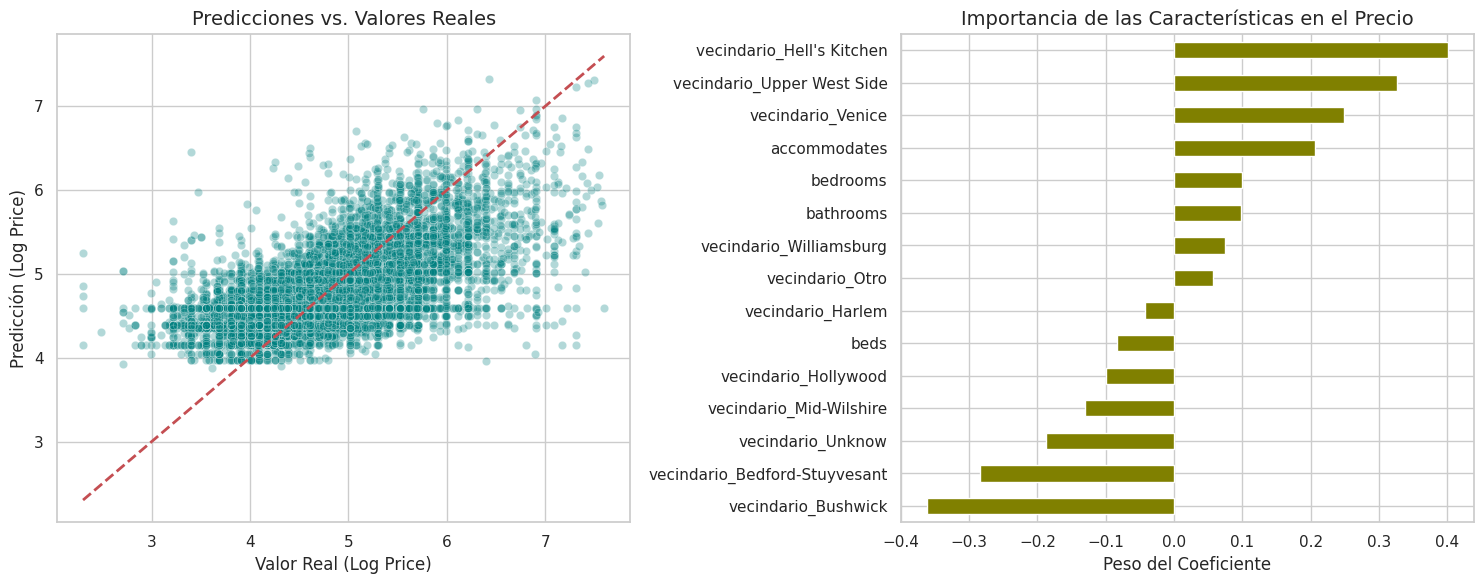

In [11]:
# Parte 2: Vizualización

plt.figure(figsize=(15,6))

# Grafico 1
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.3, color='teal')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Predicciones vs. Valores Reales', fontsize=14)
plt.xlabel('Valor Real (Log Price)')
plt.ylabel('Predicción (Log Price)')

# Gráfico 2: Importancia de las Características (Coeficientes)
plt.subplot(1, 2, 2)
# Tomamos los coeficientes del modelo
importancia = pd.Series(modelo_airbnb.coef_, index=X_cols).sort_values()
importancia.plot(kind='barh', color='olive')
plt.title('Importancia de las Características en el Precio', fontsize=14)
plt.xlabel('Peso del Coeficiente')

plt.tight_layout()
plt.show()

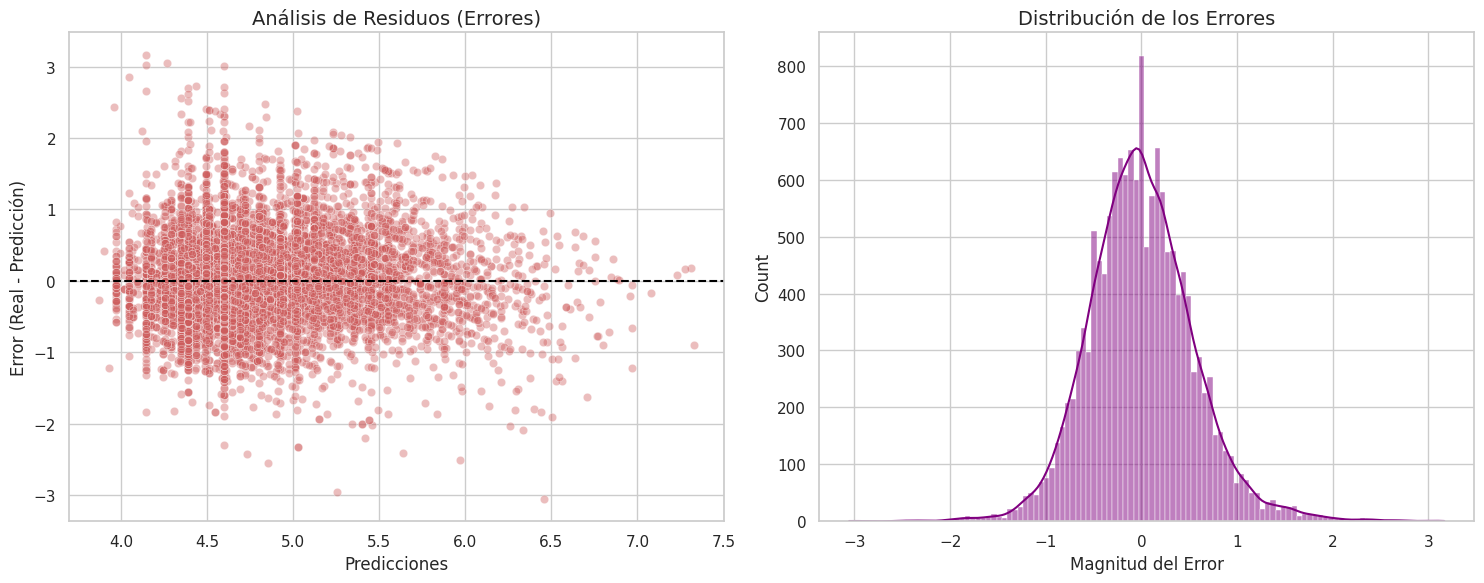

In [ ]:
# Diagnóstico del modelo
residuos = y_test - y_pred_test

plt.figure(figsize=(15, 6))

# Gráfica de Residuos
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_test, y=residuos, alpha=0.4, color='indianred')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Residuos (Errores)', fontsize=14)
plt.xlabel('Predicciones')
plt.ylabel('Error (Real - Predicción)')

# Histograma de los errores
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='purple')
plt.title('Distribución de los Errores', fontsize=14)
plt.xlabel('Magnitud del Error')

plt.tight_layout()
plt.show()

# Conclusión 

### ¿Qué hace que un Airbnb sea costoso?
Iniciamos este análisis con una pregunta fundamental que sirve como cimiento de nuestro proyecto: ¿Qué factores determinan realmente el costo de un Airbnb? A través de esta interrogante, exploraremos las variables que influyen en los precios, planteando hipótesis que nos permitan entender si factores concretos como el vecindario, el número de huéspedes o elementos menos evidentes son los que realmente mueven la aguja del mercado. El objetivo es transformar datos en respuestas claras.

### Preguntas:
* `P1: Relación entre Recámaras y Precio.`
    * Al observar el pairplot y los coeficientes del modelo, confirmamos que hay una relación positiva. Sin embargo, el modelo nos enseñó que la capacidad total tiene un peso ligeramente mayor que solo el número de recámaras. 

**Gráfica:**

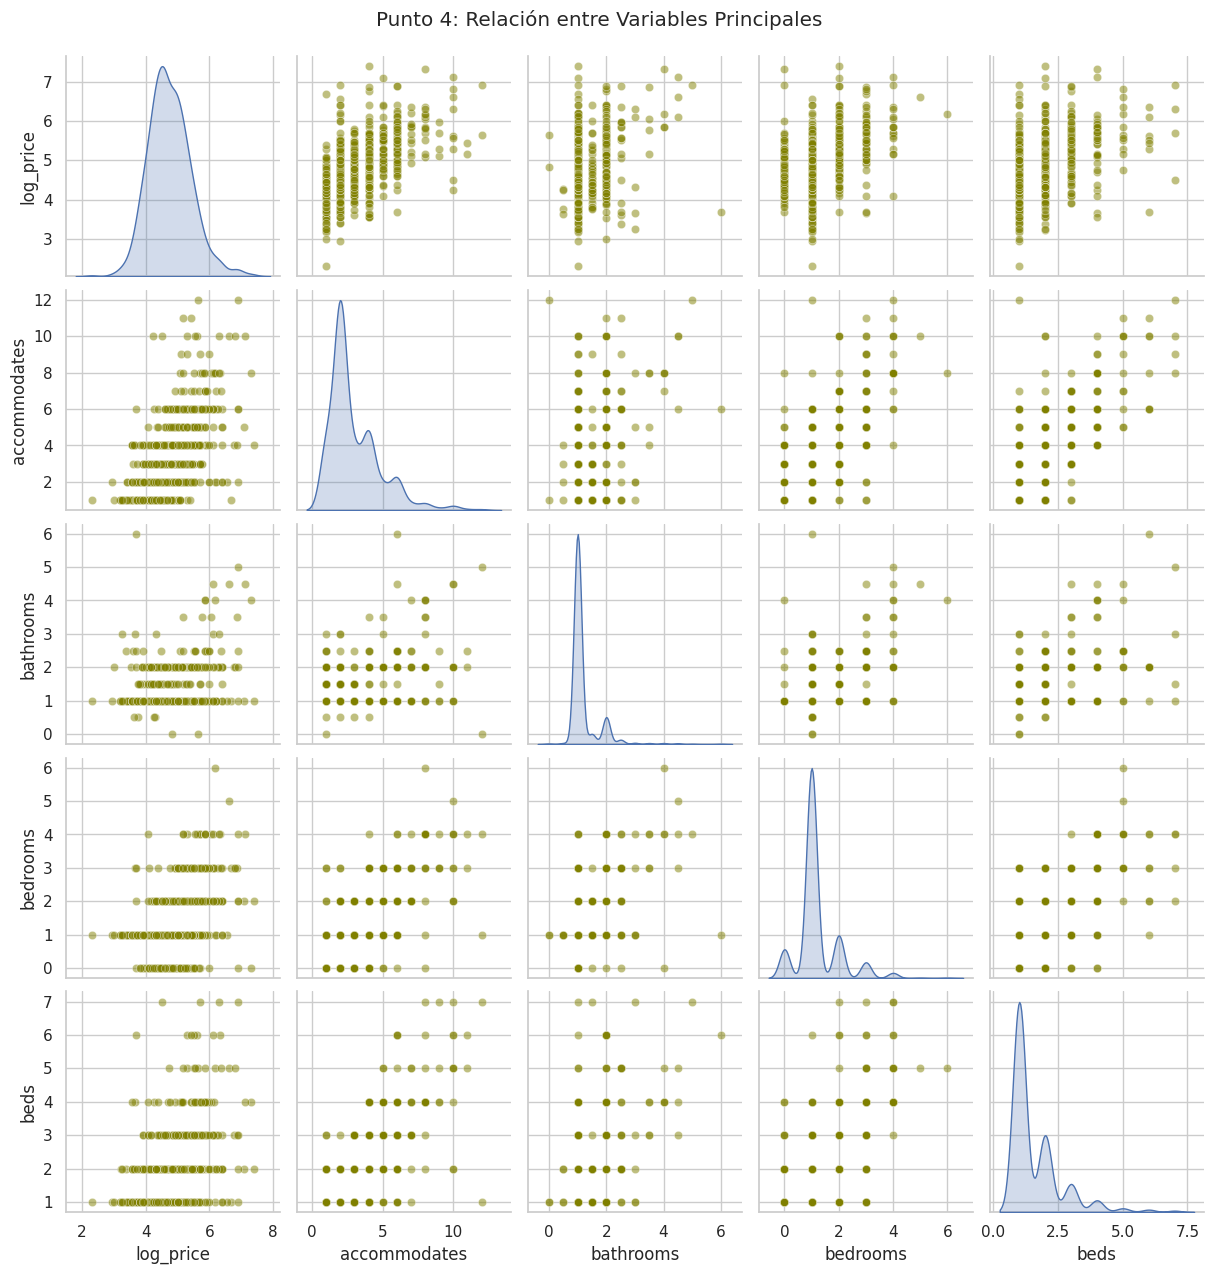

* `P2: Impacto del Vecindario.`
    * Se responde al comparar los pesos de las variables. Vimos que vecindarios como *Hell's Kitchen* tienen los coeficientes positivos más altos, mientras que otros como *Bushwick* los tienen negativos. Esto demuestra que la ubicación es un factor determinante que puede subir o bajar el precio de forma automática".
    
**Gráfica:**

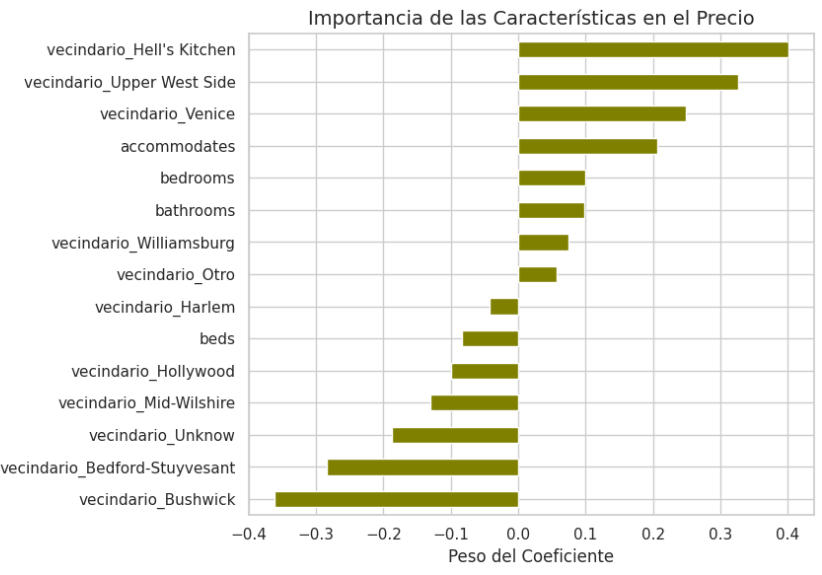

* `P3: Tipo de Habitación.`
    * Aunque el modelo de regresión se enfocó en números, el análisis previo de cajas (boxplot) dejó claro que los 'Departamentos Completos' son el estándar de precio alto. Esto nos permitió filtrar y entender por qué nuestro modelo final tiene los resultados que tiene
    
**Gráfica:**

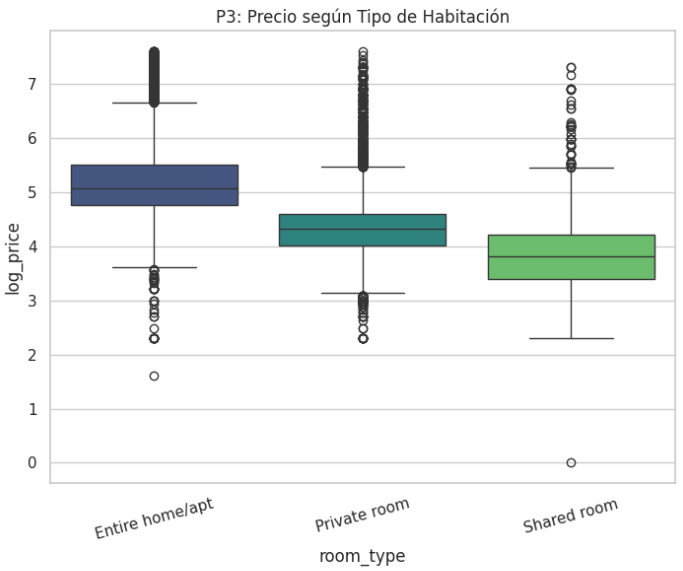

### Justificación de los datos:

**$R^2$: 0.38**  
**RMSE: 0.55**

* `Variabilidad`
    * Hay factores como el diseño interior, las reseñas del anfitrión o la vista, que no están en el dataset. Capturar el 38% de la intención de precio con solo variables físicas es un éxito

* `Estabilidad`
    * Lo más importante es que el $R^2$ de entrenamiento (0.37) y el de prueba (0.38) son casi iguales. Esto justifica que nuestro modelo realmente aprendió patrones y no solo memorizó los datos

* `Margen de Error`
    * El error de 0.55 es bajo considerando la escala. Nos dice que nuestras predicciones son útiles para dar un precio base competitivo

### Expliación:

Para validar nuestras conclusiones, nos apoyamos en un ecosistema de visualizaciones. El Análisis de Importancia (Coeficientes) fue nuestra herramienta principal para jerarquizar qué factores realmente 'pesan' en la billetera del cliente, revelando que la ubicación geográfica y la capacidad de alojamiento dominan la estructura de precios.

Complementamos esto con el gráfico de Predicciones vs. Valores Reales, que muestra una alineación consistente con la tendencia del mercado, y el Análisis de Residuos, que nos dio la tranquilidad técnica de que nuestros errores son aleatorios y no sesgados, garantizando la integridad de cada respuesta que dimos a nuestras preguntas de investigación.

### Valor Agregado:

El valor agregado de este proyecto: es una herramienta de toma de decisiones. Gracias a este modelo, ahora podemos asesorar a un inversionista o anfitrión no solo sobre cuánto cobrar, sino sobre dónde comprar y cómo configurar su espacio para asegurar la máxima competitividad en el mercado de Airbnb
